In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

# Data Cleaning

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [6]:
# Drop unuseful columns
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1, inplace=True)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Rename columns
df.rename(columns={"v1": 'spam', 'v2': 'text'}, inplace=True)

In [9]:
df.head()

,spam,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# Use label encoder for categorical value
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df['spam'] = encoder.fit_transform(df['spam'])

In [11]:
df.head()

,spam,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [12]:
# Check missing values
df.isnull().sum()

spam    0
text    0
dtype: int64

In [13]:
# Check for duplicate values
df.duplicated().sum()

np.int64(403)

In [14]:
# Remove duplicate values
df.drop_duplicates(keep='first', inplace=True)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.shape

(5169, 2)

# EDA (Exploratory Data Analysis)

In [17]:
df['spam'].value_counts()

spam
0    4516
1     653
Name: count, dtype: int64

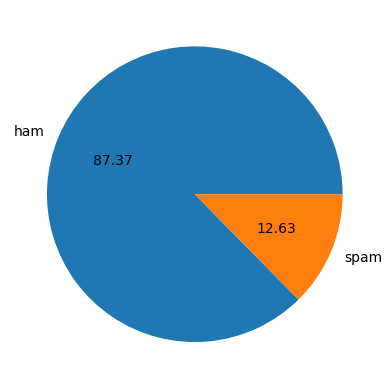

In [18]:
import matplotlib.pyplot as plt

plt.pie(df['spam'].value_counts(), labels=['ham', 'spam'], autopct='%0.2f')
plt.show()

In [19]:
# So Data is imbalanced

In [20]:
import nltk

In [21]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SARBAJIT\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [22]:
# Add no of characters
df['num_characters'] = df['text'].apply(len)
df.head()

,spam,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [23]:
# Add no of words
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df.head()

,spam,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [24]:
# Add no of sentences
df['num_sentences'] = df['text'].apply(lambda x: len(nltk.sent_tokenize(x)))
df.head()

,spam,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [25]:
df[['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
df[df['spam'] == 0][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [27]:
df[df['spam'] == 1][['num_characters', 'num_words', 'num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [28]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Density'>

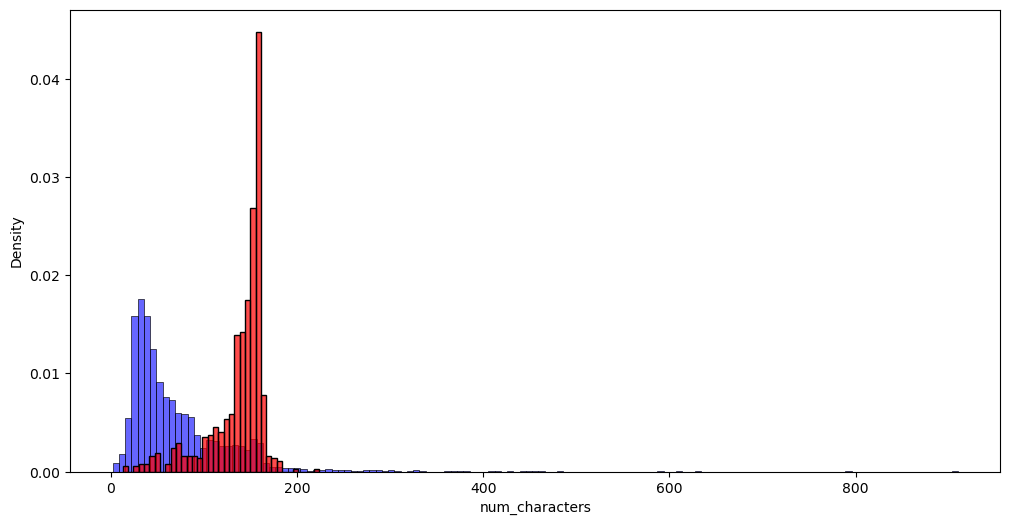

In [29]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['spam'] == 1]['num_characters'], color='red', alpha=0.7, zorder=2, stat='density')
sns.histplot(df[df['spam'] == 0]['num_characters'], color='blue', alpha=0.6, zorder=1, stat='density')
# stat density is for imbalance data set without this no samples are dominate but
# mean of them will show perfectly arount 20-80 (ham) & 120-160 (spam)

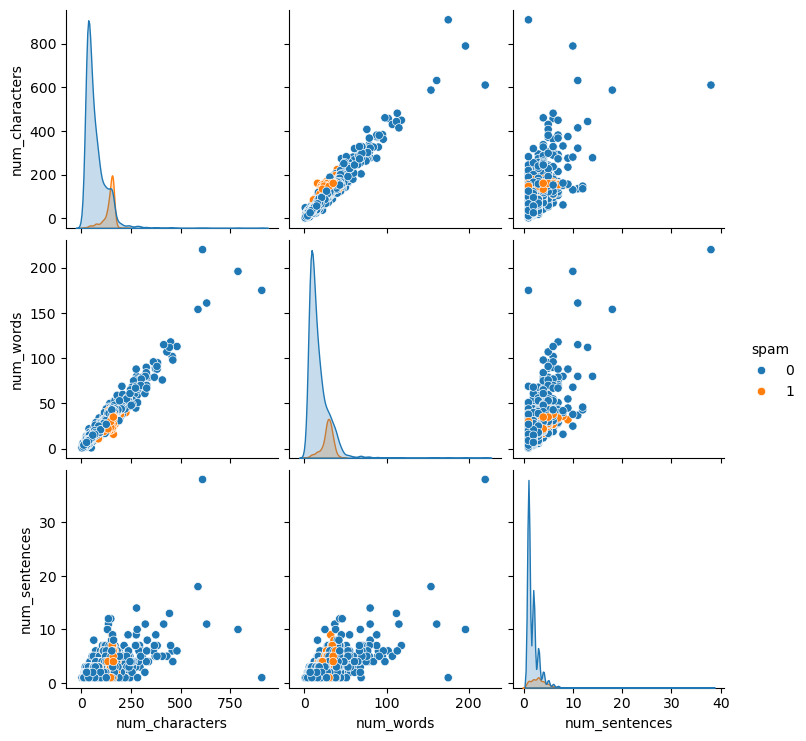

In [30]:
sns.pairplot(df,hue='spam')

In [31]:
df.corr(numeric_only=True)

,spam,num_characters,num_words,num_sentences
spam,1.000000,0.384717,0.262912,0.263939
num_characters,0.384717,1.000000,0.965760,0.624139
num_words,0.262912,0.965760,1.000000,0.679971
num_sentences,0.263939,0.624139,0.679971,1.000000


<Axes: >

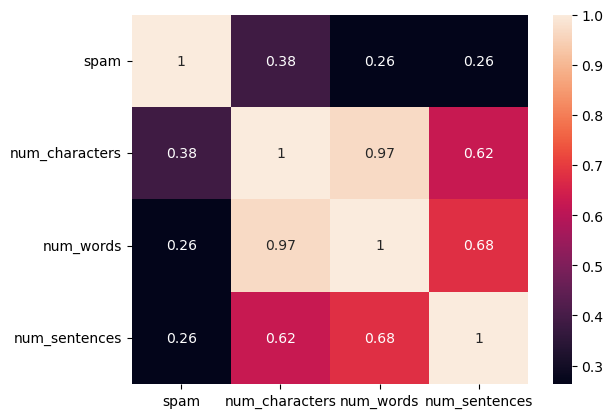

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [33]:
# num_characters are among the highest correlated with target value, we can keep this column
# and remove others because there are high correlation among them

# Data Preprocessing

- Lower case
- Tokenization
- Remove special characters
- Remove stop words and punctuation
- Stemming 

In [34]:
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [35]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SARBAJIT\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [36]:
def transform_text(text):
    text = text.lower()
    text = word_tokenize(text)
    y = []

    for word in text:
        if word.isalnum():
            y.append(word)

    text = y.copy() 
    y.clear()
    stop_words = set(stopwords.words('english'))
    for word in text:
        if word not in stop_words and word not in string.punctuation:
            y.append(word)

    text = y.copy()
    y.clear()
    for word in text:
        y.append(ps.stem(word))

    text = y.copy()
    y.clear()
    
    return " ".join(text)

In [37]:
transform_text("Hi My name is sarba and yours %% & ?")

'hi name sarba'

In [38]:
df['transformed_text'] = df['text'].apply(transform_text)

In [39]:
df.head()

,spam,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [40]:
#!pip install wordcloud
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [41]:
spam_wc = wc.generate(df[df['spam'] == 1]['transformed_text'].str.cat(sep=" "))

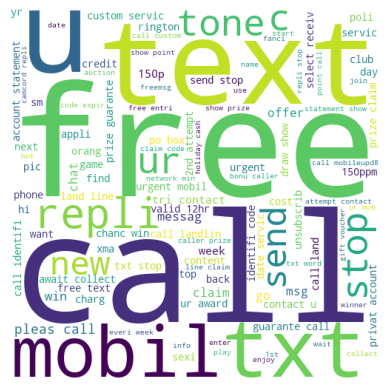

In [42]:
plt.axis('off')
plt.imshow(spam_wc)

In [43]:
ham_wc = wc.generate(df[df['spam'] == 0]['transformed_text'].str.cat(sep=" "))

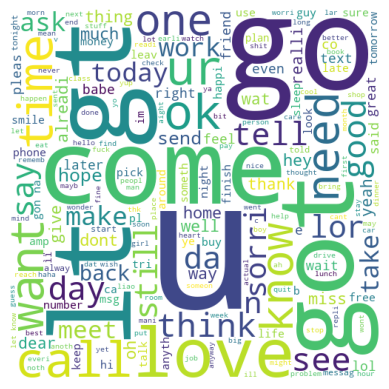

In [44]:
plt.axis('off')
plt.imshow(ham_wc)

In [45]:
spam_corpus = " ".join(df[df['spam'] == 1]['transformed_text'].tolist()).split(" ")

from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

In [46]:
spam_word_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
spam_word_df

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


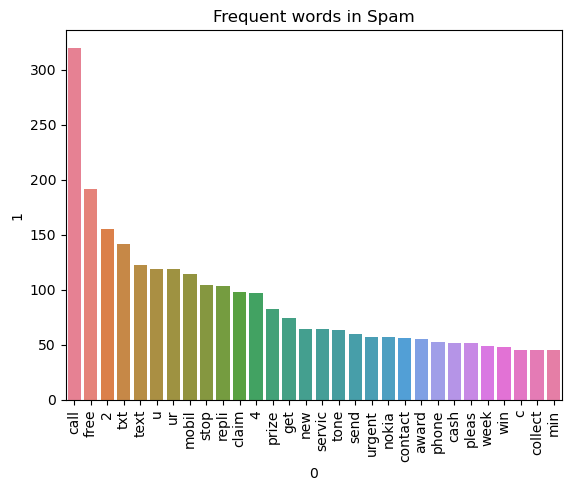

In [47]:
sns.barplot(x=spam_word_df[0], y=spam_word_df[1], hue=spam_word_df[0], palette='husl')
plt.xticks(rotation='vertical')
plt.title('Frequent words in Spam')
plt.show()

In [48]:
ham_corpus = " ".join(df[df['spam'] == 0]['transformed_text'].tolist()).split(" ")

from collections import Counter
Counter(ham_corpus).most_common(30)

[('u', 883),
 ('go', 404),
 ('get', 349),
 ('gt', 288),
 ('lt', 287),
 ('2', 284),
 ('come', 275),
 ('got', 236),
 ('know', 236),
 ('like', 234),
 ('call', 233),
 ('time', 219),
 ('ok', 217),
 ('love', 216),
 ('good', 213),
 ('want', 208),
 ('ur', 197),
 ('day', 190),
 ('need', 170),
 ('one', 165),
 ('lor', 159),
 ('4', 156),
 ('home', 152),
 ('think', 149),
 ('see', 147),
 ('take', 143),
 ('still', 143),
 ('da', 142),
 ('tell', 133),
 ('make', 129)]

In [49]:
ham_word_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
ham_word_df

,0,1
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


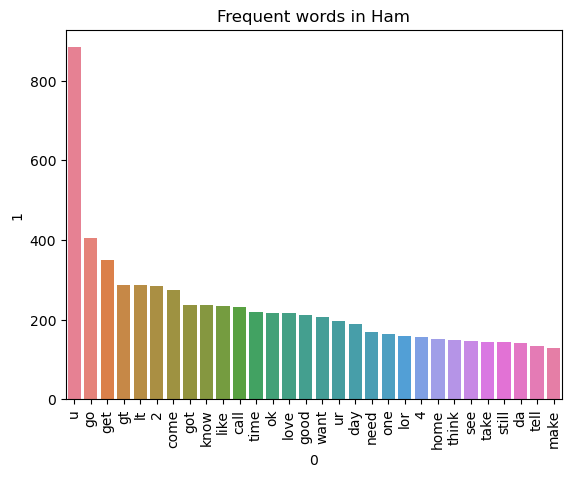

In [50]:
sns.barplot(x=ham_word_df[0], y=ham_word_df[1], hue=ham_word_df[0], palette='husl')
plt.xticks(rotation='vertical')
plt.title('Frequent words in Ham')
plt.show()

# Model Building

In [71]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [72]:
# X = cv.fit_transform(df['transformed_text']).toarray()
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [73]:
X.shape # 5169 - no of messages(row) 6708 - no of features(uniq words/col)

(5169, 3000)

In [74]:
Y = df['spam'].values

In [75]:
Y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [76]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [77]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [78]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [79]:
# GaussianNB model
gnb.fit(X_train, Y_train)
gnb_pred = gnb.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, gnb_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(Y_test, gnb_pred)}")
print(f"Precision: {precision_score(Y_test, gnb_pred)}")

Accuracy: 0.8607350096711799
Confusion Matrix:
 [[769 120]
 [ 24 121]]
Precision: 0.5020746887966805


In [80]:
# MultinomialNB model
mnb.fit(X_train, Y_train)
mnb_pred = mnb.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, mnb_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(Y_test, mnb_pred)}")
print(f"Precision: {precision_score(Y_test, mnb_pred)}")

Accuracy: 0.9729206963249516
Confusion Matrix:
 [[888   1]
 [ 27 118]]
Precision: 0.9915966386554622


In [81]:
# BernoulliNB model
bnb.fit(X_train, Y_train)
bnb_pred = bnb.predict(X_test)
print(f"Accuracy: {accuracy_score(Y_test, bnb_pred)}")
print(f"Confusion Matrix:\n {confusion_matrix(Y_test, bnb_pred)}")
print(f"Precision: {precision_score(Y_test, bnb_pred)}")

Accuracy: 0.9729206963249516
Confusion Matrix:
 [[884   5]
 [ 23 122]]
Precision: 0.9606299212598425


#### NOTE - After using TF-IDF vectorization method the model precision(FP) is increased so well for MultinomialNB and BernoulliNB

## Compare verious Models & evaluate them

In [62]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [63]:
lr = LogisticRegression()
svc = SVC()
mnb = MultinomialNB()
knn = KNeighborsClassifier()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()

In [64]:
models = {
    'Logistic Regression': LogisticRegression(),
    'SVC': SVC(),
    'Multinomial NB': MultinomialNB(),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Gradient Boosting': GradientBoostingClassifier()
}

In [65]:
def train_classifier(clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    clf_pred = clf.predict(X_test)
    clf_acc = accuracy_score(y_test, clf_pred)
    clf_pre = precision_score(y_test, clf_pred)

    return clf_acc, clf_pre

In [66]:
accuracy_scores = []
precision_scores = []
model_names = []

for name, clf in models.items():
    acc, pre = train_classifier(clf, X_train, X_test, Y_train, Y_test)

    print(f"Accuracy for {name}: {acc}")
    print(f"Precision for {name}: {pre}")

    model_names.append(name)
    accuracy_scores.append(acc)
    precision_scores.append(pre)


Accuracy for Logistic Regression: 0.9487427466150871
Precision for Logistic Regression: 0.9423076923076923
Accuracy for SVC: 0.9680851063829787
Precision for SVC: 0.9912280701754386
Accuracy for Multinomial NB: 0.9613152804642167
Precision for Multinomial NB: 0.9906542056074766
Accuracy for KNN: 0.8965183752417795
Precision for KNN: 1.0
Accuracy for Decision Tree: 0.9526112185686654
Precision for Decision Tree: 0.8287671232876712
Accuracy for Random Forest: 0.9680851063829787
Precision for Random Forest: 0.9912280701754386
Accuracy for Gradient Boosting: 0.9632495164410058
Precision for Gradient Boosting: 0.9572649572649573


In [67]:
performance_df = pd.DataFrame({
    'Algorithm': model_names, 
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

performance_df.sort_values('Precision',ascending=False,)

,Algorithm,Accuracy,Precision
3,KNN,0.896518,1.000000
1,SVC,0.968085,0.991228
5,Random Forest,0.968085,0.991228
2,Multinomial NB,0.961315,0.990654
6,Gradient Boosting,0.963250,0.957265
0,Logistic Regression,0.948743,0.942308
4,Decision Tree,0.952611,0.828767


In [68]:
performance_df2 = pd.melt(performance_df, id_vars='Algorithm')
performance_df2

,Algorithm,variable,value
0,Logistic Regression,Accuracy,0.948743
1,SVC,Accuracy,0.968085
2,Multinomial NB,Accuracy,0.961315
3,KNN,Accuracy,0.896518
4,Decision Tree,Accuracy,0.952611
5,Random Forest,Accuracy,0.968085
6,Gradient Boosting,Accuracy,0.963250
7,Logistic Regression,Precision,0.942308
8,SVC,Precision,0.991228
9,Multinomial NB,Precision,0.990654


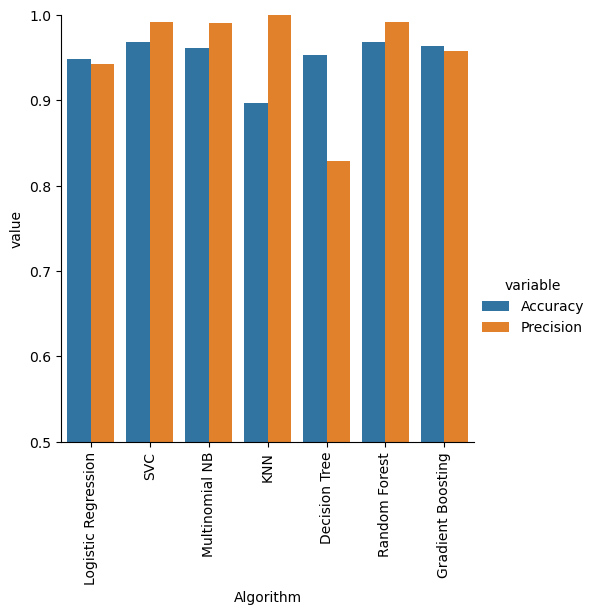

In [69]:
sns.catplot(
    x='Algorithm',
    y='value',
    hue='variable',
    data=performance_df2,
    kind='bar',
    height=5
)

plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')

plt.show()

In [70]:
import joblib

In [82]:
joblib.dump(tfidf, 'vectorizer.pkl')
joblib.dump(mnb, 'model.pkl')

['model.pkl']